# ====================================
# STEP 4: DATA AUGMENTATION
# ====================================

In [22]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras import models

In [23]:
data_augmentation = tf.keras.Sequential([

    layers.RandomRotation(0.05),

    layers.RandomZoom(0.1),

    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    )

], name="data_augmentation")

In [24]:
import tensorflow as tf

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

print("Dataset Loaded Successfully")

Found 5216 files belonging to 2 classes.
Dataset Loaded Successfully


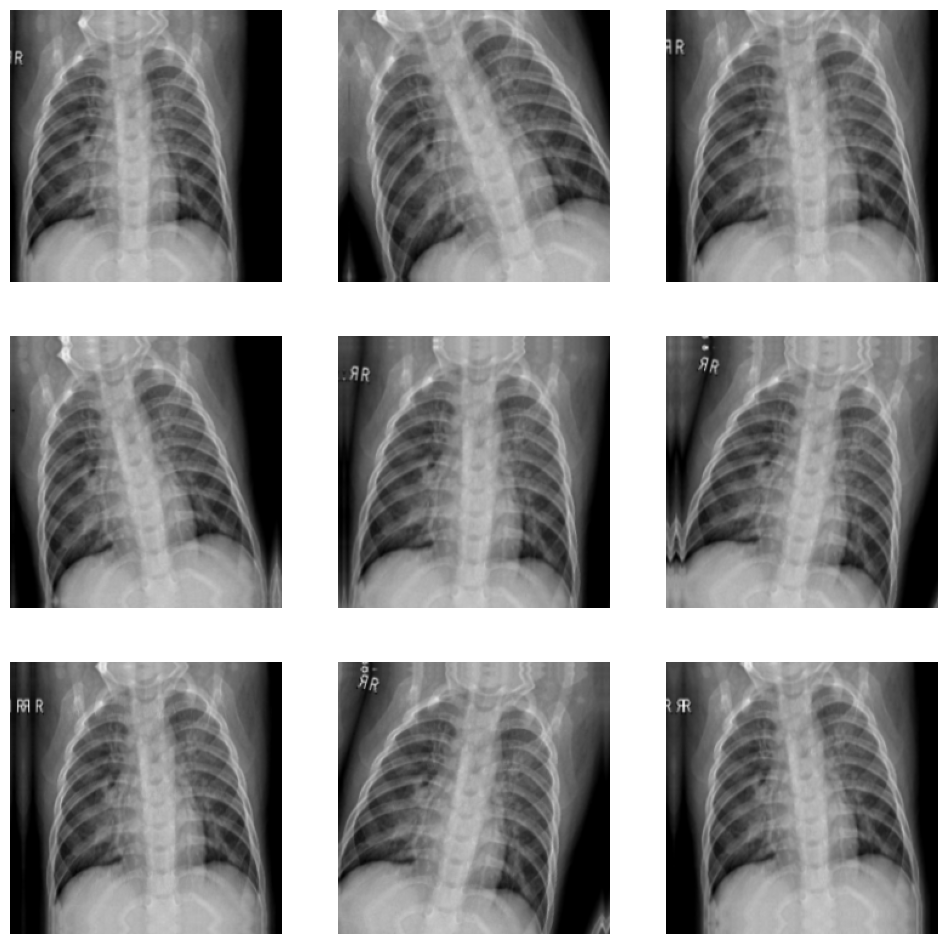

In [25]:
for images, labels in train_dataset.take(1):

    sample_image = images[0]

    plt.figure(figsize=(12, 12))

    for i in range(9):

        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, axis=0)
        )

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            augmented_image[0].numpy() / 255.0,
            cmap="gray"
        )

        plt.axis("off")

    plt.show()

In [26]:
for images, labels in train_dataset.take(1):

    print("Min:", tf.reduce_min(images).numpy())
    print("Max:", tf.reduce_max(images).numpy())

    break

Min: 0.0
Max: 255.0


Building CNN model

In [27]:
model = models.Sequential([

    # Data Augmentation
    data_augmentation,

    # Normalization
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(),

    # Classifier
    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )

])

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 222, 222, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 111, 111, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 109, 109, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 54, 54, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 52, 52, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (1, 26, 26, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 86528)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 1)                 │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [31]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [33]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/val",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary"
)

print("Validation Dataset Loaded")

Found 16 files belonging to 2 classes.
Validation Dataset Loaded


In [34]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - accuracy: 0.8221 - loss: 0.4014 - val_accuracy: 0.7500 - val_loss: 0.5590
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.8965 - loss: 0.2503 - val_accuracy: 0.7500 - val_loss: 0.6222
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9237 - loss: 0.2019 - val_accuracy: 0.8125 - val_loss: 0.5192
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.9306 - loss: 0.1791 - val_accuracy: 0.8750 - val_loss: 0.3234
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.9381 - loss: 0.1659 - val_accuracy: 0.7500 - val_loss: 0.6410
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.9408 - loss: 0.1523 - val_accuracy: 0.6875 - val_loss: 1.4172
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.9465 - loss: 0.1454 - val_accuracy: 0.8750 - val_loss: 0.2746
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.9482 - loss: 0.1387 - val_accu

In [36]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "../data/test",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary"
)

print("Test Dataset Loaded Successfully")

Found 624 files belonging to 2 classes.
Test Dataset Loaded Successfully


Evaluation

In [37]:
model.evaluate(test_dataset)

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 305ms/step - accuracy: 0.8413 - loss: 0.5443


[0.544305145740509, 0.8413461446762085]

In [38]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 235ms/step - accuracy: 0.8413 - loss: 0.5443
Test Loss: 0.5443
Test Accuracy: 0.8413


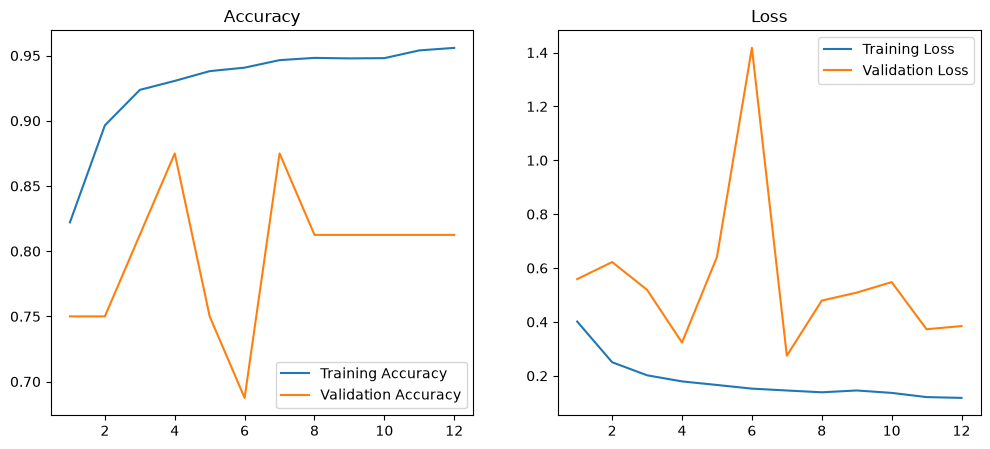

In [40]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(accuracy) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(epochs, accuracy, label="Training Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")

plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.title("Loss")
plt.legend()

plt.show()

In [41]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())

    y_pred.extend(predictions)

In [42]:
y_true = np.array(y_true).flatten()

y_pred = np.array(y_pred).flatten()

print(y_true.shape)
print(y_pred.shape)

(624,)
(624,)


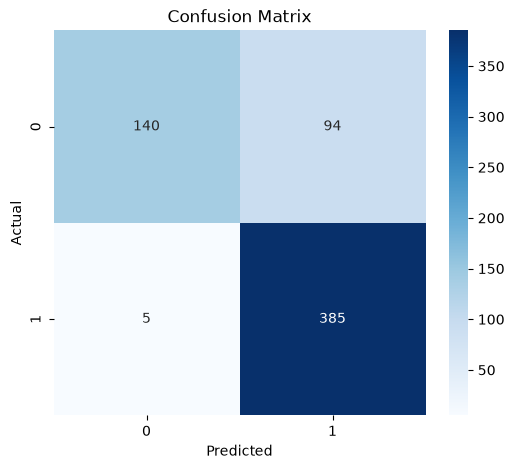

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [44]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NORMAL",
            "PNEUMONIA"
        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.97      0.60      0.74       234
   PNEUMONIA       0.80      0.99      0.89       390

    accuracy                           0.84       624
   macro avg       0.88      0.79      0.81       624
weighted avg       0.86      0.84      0.83       624



In [45]:
model.save(
    "../models/custom_cnn.keras"
)